# Сергушов Павел ПМ22-4


# Задача 1

Запустите у себя код из лекции в пункте "Реализация примера сети U-Net вручную"

Увеличьте глубину UNet с дополнительными слоями. Для этого:

1. Добавьте еще один down/up блок (вместо 5 уровней сделайте 6)

2. Убедитесь, что размеры тензоров правильно согласованы

Посмотрите как это отразиться на результате

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [4]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


In [5]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


In [6]:
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


In [7]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        factor = 2 if bilinear else 1
        self.down5 = Down(1024, 2048 // factor) # Новый добавленный слой

        # Модифицированные и добавленные Up слои
        self.up1 = Up(2048, 1024 // factor, bilinear) # Новый Up слой
        self.up2 = Up(1024, 512 // factor, bilinear)
        self.up3 = Up(512, 256 // factor, bilinear)
        self.up4 = Up(256, 128 // factor, bilinear)
        self.up5 = Up(128, 64, bilinear) # Последний Up слой (был up4)

        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x6 = self.down5(x5) # Выход нового Down слоя

        # Путь расширения (Decoder)
        x = self.up1(x6, x5) # Используем выход x6 и skip connection x5
        x = self.up2(x, x4)
        x = self.up3(x, x3)
        x = self.up4(x, x2)
        x = self.up5(x, x1) # Используем выход последнего Up и skip connection x1
        logits = self.outc(x)
        return logits



In [8]:
# Задайте параметры входа/выхода
input_channels = 3  # Например, для RGB изображения
num_classes = 1     # Например, для бинарной сегментации
input_height = 256  # Пример высоты
input_width = 256   # Пример ширины


In [9]:
# Убедитесь, что H и W делятся на 2^5 = 32 из-за 5 слоев Max Pooling
if input_height % 32 != 0 or input_width % 32 != 0:
     print(f"Warning: Input height/width should be divisible by 32 for 6 levels. Adjusting size.")
     input_height = (input_height // 32) * 32
     input_width = (input_width // 32) * 32
     if input_height == 0 or input_width == 0:
         # Handle case where input is too small
         input_height = 32
         input_width = 32
         print(f"Input size too small, setting to minimum {input_height}x{input_width}")


input_tensor = torch.randn(1, input_channels, input_height, input_width) # Batch size 1


In [10]:
model = UNet(n_channels=input_channels, n_classes=num_classes, bilinear=True)


In [11]:
output = model(input_tensor)

# Печатаем формы тензоров для проверки
print(f"Input shape: {input_tensor.shape}")
print(f"Output shape: {output.shape}")


Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


# Задача 2

Пользуясь примером из лекции для сети U-Net на основе VGG16_bn, задайте архитектуру на основе ResNet, проведите обучение на том же датасете.

In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet34 # Импортируем ResNet34
from PIL import Image
import numpy as np
from tqdm import tqdm # для прогресс-бара

In [14]:
# Загрузка данных (выполняется один раз)
if not os.path.exists('SegNet-Tutorial-master'):
    print("Downloading and extracting CamVid dataset...")
    # Используем немного другую ссылку/структуру, которая часто используется для CamVid
    if not os.path.exists('camvid'):
        !pip install gdown -q
        !gdown --id 17-Rvs_Z8Kslp3m9Zggkfzqo1dkymbXJ- # Загрузка CamVid из Google Drive
        !unzip -q camvid.zip
        !rm camvid.zip
    # Если предыдущая команда не сработала или у вас уже есть SegNet-Tutorial-master:
    elif not os.path.exists('SegNet-Tutorial-master/CamVid'):
         !wget https://github.com/alexgkendall/SegNet-Tutorial/archive/refs/heads/master.zip -O camvid_segnet.zip
         !unzip -q camvid_segnet.zip
         !rm camvid_segnet.zip
         # Убедимся, что директория называется 'SegNet-Tutorial-master'
         if not os.path.exists('SegNet-Tutorial-master'):
             # Переименуем если нужно (имя может отличаться в зависимости от версии zip)
             if os.path.exists('SegNet-Tutorial-master'): # Пример имени папки после распаковки
                 os.rename('SegNet-Tutorial-master', 'SegNet-Tutorial-master') # Замените на актуальное имя если нужно
             else:
                 print("Could not find the extracted folder. Please check the name after unzipping.")
    DATA_DIR = 'camvid' if os.path.exists('camvid') else 'SegNet-Tutorial-master/CamVid' # Определяем директорию
else:
    DATA_DIR = 'camvid' if os.path.exists('camvid') else 'SegNet-Tutorial-master/CamVid'
    print(f"Dataset found in {DATA_DIR}")

# Проверка наличия директорий
print(f"Using dataset directory: {DATA_DIR}")
print(f"Train images exist: {os.path.exists(os.path.join(DATA_DIR, 'train'))}")
print(f"Train labels exist: {os.path.exists(os.path.join(DATA_DIR, 'trainannot'))}")
print(f"Val images exist: {os.path.exists(os.path.join(DATA_DIR, 'val'))}")
print(f"Val labels exist: {os.path.exists(os.path.join(DATA_DIR, 'valannot'))}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Dataset found in SegNet-Tutorial-master/CamVid
Using dataset directory: SegNet-Tutorial-master/CamVid
Train images exist: True
Train labels exist: True
Val images exist: True
Val labels exist: True
Using device: cuda


In [ ]:
# --- Вспомогательные блоки ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UpConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)


    def forward(self, x):
        return self.up(x)
# --- Класс Датасета ---
class CamVidDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, target_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.target_transform = target_transform
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        # Убедимся, что файлы совпадают (простая проверка по количеству)
        assert len(self.images) == len(self.masks), "Number of images and masks must match"


    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx]) # Имена масок должны совпадать с именами картинок

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") # Загружаем как grayscale

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            mask = self.target_transform(mask)

        mask = np.array(mask)
        mask = torch.from_numpy(mask).long() 

        return image, mask

# --- Трансформации ---
img_size = (256, 256) # Уменьшим размер для ускорения обучения/экономии памяти
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Трансформация для масок (только изменение размера, без нормализации!)
mask_transform = transforms.Compose([
    transforms.Resize(img_size, interpolation=transforms.InterpolationMode.NEAREST), # Nearest для сохранения индексов классов
])

In [16]:
class ResNetUNet(nn.Module):
    def __init__(self, n_classes=12, pretrained=True):
        super().__init__()
        self.n_classes = n_classes

        # Загружаем ResNet34
        resnet = resnet34(weights='ResNet34_Weights.DEFAULT' if pretrained else None)

        # --- Энкодер ---
        # Начальный блок
        self.init_conv = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        ) # Output: 64 channels, H/2, W/2
        self.init_pool = resnet.maxpool # Output: 64 channels, H/4, W/4

        # Слои ResNet
        self.encoder1 = resnet.layer1 # Output: 64 channels, H/4, W/4
        self.encoder2 = resnet.layer2 # Output: 128 channels, H/8, W/8
        self.encoder3 = resnet.layer3 # Output: 256 channels, H/16, W/16
        self.encoder4 = resnet.layer4 # Output: 512 channels, H/32, W/32 (это наш bottleneck)

        # --- Декодер ---
        # Каналы после каждого слоя энкодера (для skip connections)
        # init_conv: 64, encoder1: 64, encoder2: 128, encoder3: 256, encoder4: 512

        # Up 1 (из encoder4)
        self.upconv1 = UpConv(512, 256) # H/16, W/16
        self.decoder1 = DoubleConv(256 + 256, 256) # concat(upconv1, encoder3)

        # Up 2
        self.upconv2 = UpConv(256, 128) # H/8, W/8
        self.decoder2 = DoubleConv(128 + 128, 128) # concat(upconv2, encoder2)

        # Up 3
        self.upconv3 = UpConv(128, 64) # H/4, W/4
        self.decoder3 = DoubleConv(64 + 64, 64)   # concat(upconv3, encoder1)

        # Up 4 (обратно к H/2, W/2) - используем init_conv как skip connection
        self.upconv4 = UpConv(64, 64) # H/2, W/2
        self.decoder4 = DoubleConv(64 + 64, 64) # concat(upconv4, init_conv output)

        # Финальное повышение разрешения до H, W
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # Энкодер
        x_init = self.init_conv(x)     # H/2, W/2, 64
        x_pool = self.init_pool(x_init) # H/4, W/4, 64

        e1 = self.encoder1(x_pool) # H/4, W/4, 64
        e2 = self.encoder2(e1)     # H/8, W/8, 128
        e3 = self.encoder3(e2)     # H/16, W/16, 256
        e4 = self.encoder4(e3)     # H/32, W/32, 512 (bottleneck)

        # Декодер
        d1 = self.upconv1(e4)      # H/16, W/16, 256
        # print("d1:", d1.shape, "e3:", e3.shape) # Для отладки размеров
        d1 = torch.cat([d1, e3], dim=1) # 256 + 256 = 512
        d1 = self.decoder1(d1)     # H/16, W/16, 256

        d2 = self.upconv2(d1)      # H/8, W/8, 128
        # print("d2:", d2.shape, "e2:", e2.shape)
        d2 = torch.cat([d2, e2], dim=1) # 128 + 128 = 256
        d2 = self.decoder2(d2)     # H/8, W/8, 128

        d3 = self.upconv3(d2)      # H/4, W/4, 64
        # print("d3:", d3.shape, "e1:", e1.shape)
        d3 = torch.cat([d3, e1], dim=1) # 64 + 64 = 128
        d3 = self.decoder3(d3)     # H/4, W/4, 64

        d4 = self.upconv4(d3)      # H/2, W/2, 64
        # print("d4:", d4.shape, "x_init:", x_init.shape)
        d4 = torch.cat([d4, x_init], dim=1) # 64 + 64 = 128
        d4 = self.decoder4(d4)     # H/2, W/2, 64

        out = self.final_up(d4)    # H, W, 32
        out = self.final_conv(out) # H, W, n_classes

        return out

Train dataset size: 367
Validation dataset size: 101


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 157MB/s]


Starting Training...

Epoch 1/25


Validation: 100%|██████████| 13/13 [00:01<00:00, 11.14it/s, loss=1.93]


Epoch 1: Train Loss: 2.1663, Val Loss: 1.9515

Epoch 2/25


...

Epoch 23: Train Loss: 0.2206, Val Loss: 0.3947

Epoch 24/25


Validation: 100%|██████████| 13/13 [00:01<00:00, 11.35it/s, loss=0.415]


Epoch 24: Train Loss: 0.2156, Val Loss: 0.3887

Epoch 25/25


Validation: 100%|██████████| 13/13 [00:01<00:00, 11.40it/s, loss=0.427]


Epoch 25: Train Loss: 0.2083, Val Loss: 0.3963
Training Finished!


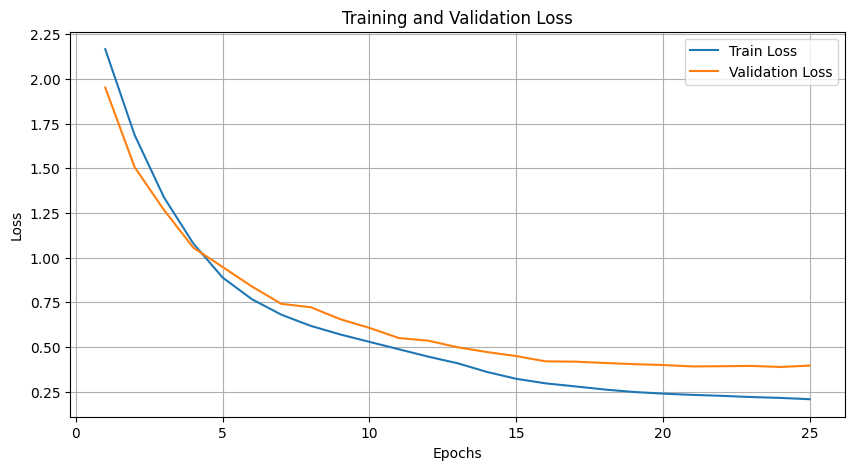

In [ ]:
# --- Параметры ---
NUM_CLASSES = 12
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 25

# --- Создание Датасетов и Загрузчиков ---
train_img_dir = os.path.join(DATA_DIR, 'train')
train_mask_dir = os.path.join(DATA_DIR, 'trainannot')
val_img_dir = os.path.join(DATA_DIR, 'val')
val_mask_dir = os.path.join(DATA_DIR, 'valannot')

train_dataset = CamVidDataset(train_img_dir, train_mask_dir, transform=train_transform, target_transform=mask_transform)
val_dataset = CamVidDataset(val_img_dir, val_mask_dir, transform=val_transform, target_transform=mask_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# --- Инициализация Модели, Функции Потерь и Оптимизатора ---
model = ResNetUNet(n_classes=NUM_CLASSES, pretrained=True).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=11) 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
# --- Цикл Обучения ---
    pbar = tqdm(loader, desc="Training")
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device) 

        optimizer.zero_grad()
        outputs = model(images) # [N, C, H, W]

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=loss.item()) # Показываем текущий батч лосс

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation")
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item() * images.size(0)
            pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

# --- Запуск обучения ---
train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("Training Finished!")

# --- Визуализация потерь (опционально) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()